# Task 3: Model Optimization

Enhancing model performance using **Hyperparameter Tuning** and **Regularization**, and comparing different versions of the model (baseline vs optimized) using scikit-learn.

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 2. Load and Prepare the Dataset

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## 3. Baseline Models (Before Optimization)

Train each model using default hyperparameters to establish a baseline.

In [4]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
}

baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.973684,0.979021
1,Decision Tree,0.947368,0.957746
2,SVM,0.982456,0.986111


## 4. Hyperparameter Tuning with GridSearchCV

Search for the best combination of hyperparameters for each model using 5-fold cross-validation.

In [5]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"],
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.01, 0.001],
        "kernel": ["rbf"],
    },
}

base_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
}

best_estimators = {}
best_params = {}

for name, estimator in base_estimators.items():
    grid = GridSearchCV(estimator, param_grids[name], cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_estimators[name] = grid.best_estimator_
    best_params[name] = grid.best_params_
    print(name, "->", grid.best_params_)

Logistic Regression -> {'C': 10}
Decision Tree -> {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
SVM -> {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


## 5. Regularization Effect on Logistic Regression

Visualizing how the regularization strength (`C`) affects training vs test accuracy. Smaller `C` means stronger regularization.

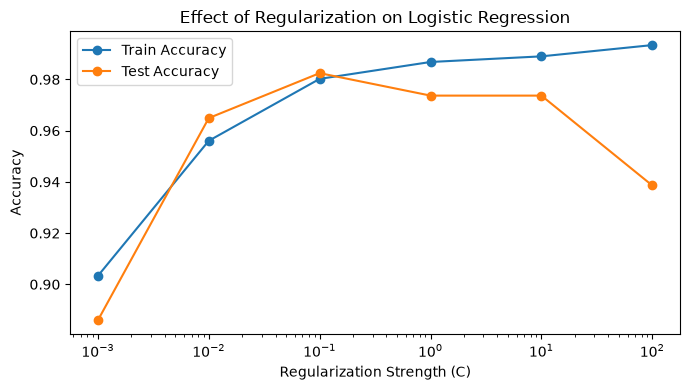

In [6]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for c in C_values:
    lr = LogisticRegression(C=c, max_iter=5000)
    lr.fit(X_train_scaled, y_train)
    train_scores.append(lr.score(X_train_scaled, y_train))
    test_scores.append(lr.score(X_test_scaled, y_test))

plt.figure(figsize=(7, 4))
plt.plot(C_values, train_scores, marker="o", label="Train Accuracy")
plt.plot(C_values, test_scores, marker="o", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization on Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate Optimized Models on Test Set

In [7]:
optimized_results = []
for name, model in best_estimators.items():
    y_pred = model.predict(X_test_scaled)
    optimized_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

optimized_df = pd.DataFrame(optimized_results)
optimized_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.973684,0.978723
1,Decision Tree,0.956140,0.965517
2,SVM,0.982456,0.986111


## 7. Compare Baseline vs Optimized Performance

In [8]:
comparison_df = baseline_df.merge(
    optimized_df, on="Model", suffixes=(" (Baseline)", " (Optimized)")
)
comparison_df

,Model,Accuracy (Baseline),F1 Score (Baseline),Accuracy (Optimized),F1 Score (Optimized)
0,Logistic Regression,0.973684,0.979021,0.973684,0.978723
1,Decision Tree,0.947368,0.957746,0.956140,0.965517
2,SVM,0.982456,0.986111,0.982456,0.986111


## 8. Visualize Baseline vs Optimized Accuracy

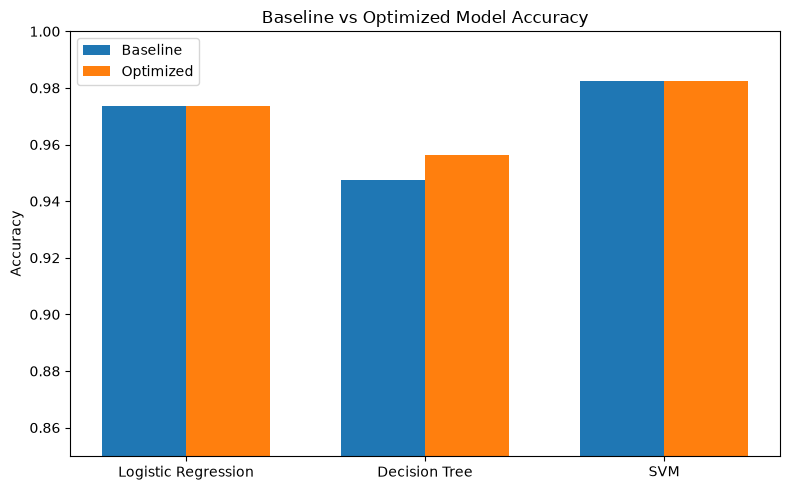

In [9]:
x = range(len(comparison_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], comparison_df["Accuracy (Baseline)"], width, label="Baseline")
plt.bar([i + width/2 for i in x], comparison_df["Accuracy (Optimized)"], width, label="Optimized")
plt.xticks(list(x), comparison_df["Model"])
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.title("Baseline vs Optimized Model Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrix — Best Optimized Model

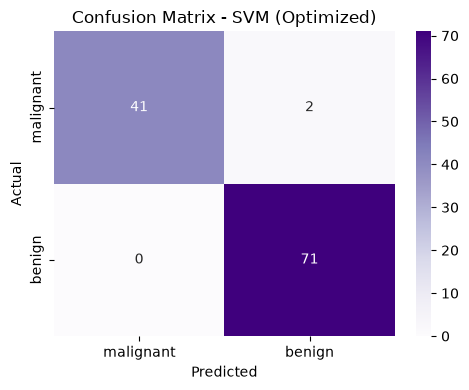

In [10]:
best_model_name = optimized_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f"Confusion Matrix - {best_model_name} (Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 10. Best Hyperparameters Summary

In [11]:
for name, params in best_params.items():
    print(name, ":", params)

print()
print("Best overall model after optimization:", best_model_name)

Logistic Regression : {'C': 10}
Decision Tree : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
SVM : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best overall model after optimization: SVM


## 11. Validate with Sample Test Cases

In [13]:
sample = X_test_scaled[:5]
sample_true = y_test.iloc[:5].values
sample_pred = best_model.predict(sample)

for i in range(5):
    label_true = data.target_names[sample_true[i]]
    label_pred = data.target_names[sample_pred[i]]
    match = "correct" if sample_true[i] == sample_pred[i] else "WRONG"
    print(f"True: {label_true:10s} | Predicted: {label_pred:10s} | {match}")

True: benign     | Predicted: benign     | correct
True: malignant  | Predicted: malignant  | correct
True: malignant  | Predicted: malignant  | correct
True: benign     | Predicted: benign     | correct
True: benign     | Predicted: benign     | correct
